# Part 3: Advanced Clustering with PCA & t-SNE
We are now clustering based on **RFM, Product Diversity, and Geography**. 
Because we have mixed data types, we use PCA to reduce dimensions before 
applying K-Means and DBSCAN.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Add src to path
sys.path.append('../')
from src.utils import save_plot

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load Data and Reduce Dimensions
We use PCA to ensure our categorical 'Country' features and numerical 'RFM' 
features are weighted equally before clustering.

In [2]:
# Load scaled data
X = pd.read_csv('../data/processed/rfm_scaled.csv', index_col='Customer ID')

# Reduce to 90% variance
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Features reduced from {X.shape[1]} to {X_pca.shape[1]} PCA components.")

Features reduced from 3 to 2 PCA components.


## 2. The Elbow Method & Silhouette Analysis
We look for the "Elbow" where inertia starts to level off, and the peak of the 
Silhouette score to find the mathematical 'best' fit.

Plot saved: ..\plots\clustering\clustering_optimization.png


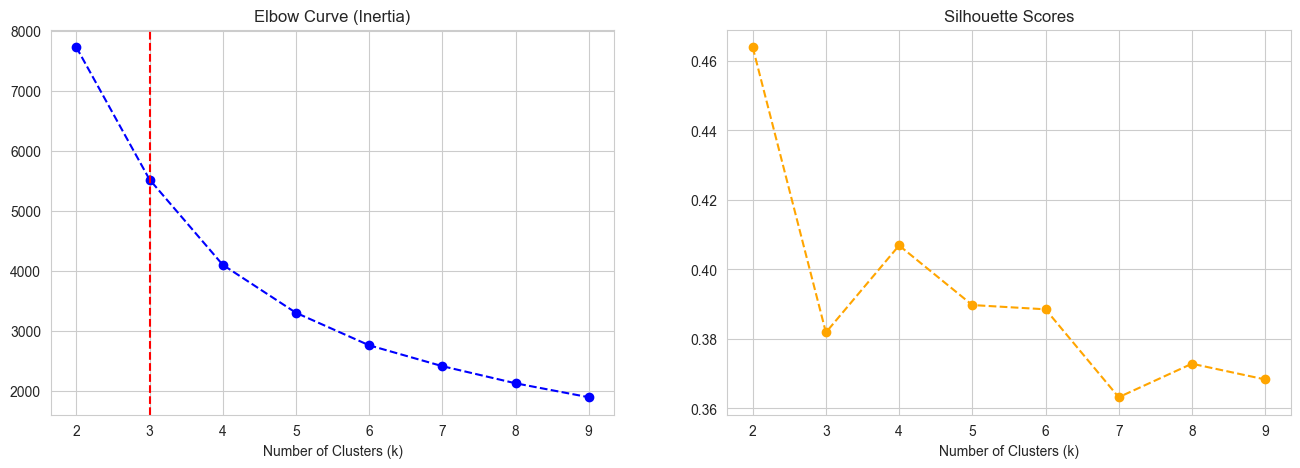

In [3]:
inertia = []
silhouette_avgs = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    silhouette_avgs.append(silhouette_score(X_pca, labels))

# Plotting the Results
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Curve
ax[0].plot(k_range, inertia, marker='o', linestyle='--', color='b')
ax[0].set_title('Elbow Curve (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].axvline(x=3, color='r', linestyle='--') # Mark the elbow

# Silhouette Score
ax[1].plot(k_range, silhouette_avgs, marker='o', linestyle='--', color='orange')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Number of Clusters (k)')

save_plot('clustering_optimization.png', folder='clustering')
plt.show()

## 3. Final Model Execution (K=3)
Based on the elbow at 3 and the high silhouette score, we proceed with 3 clusters.

In [4]:
# Fit K-Means
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca)

# Fit DBSCAN (Density-based comparison)
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)

# Save results for the next notebook
results = pd.DataFrame({
    'KMeans': km_labels,
    'DBSCAN': db_labels
}, index=X.index)

results.to_csv('../data/processed/cluster_results.csv')
print("Clustering labels saved successfully.")

Clustering labels saved successfully.


## 4. t-SNE Visualization
Finally, we project the high-dimensional data into 2D to see how well our 
3 clusters are separated.

Plot saved: ..\plots\clustering\tsne_final_k3.png


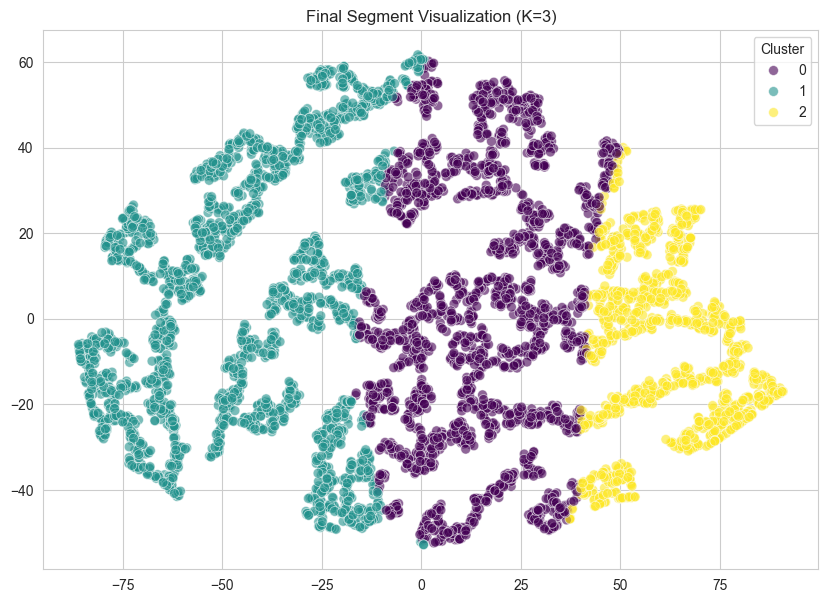

In [5]:
# Projecting PCA data into 2D t-SNE
tsne = TSNE(n_components=2, perplexity=35, random_state=42)
tsne_results = tsne.fit_transform(X_pca)

# Create Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1], 
    hue=km_labels, palette='viridis', 
    s=50, alpha=0.6, edgecolor='w'
)

plt.title(f'Final Segment Visualization (K={best_k})')
plt.legend(title='Cluster', loc='upper right')

save_plot('tsne_final_k3.png', folder='clustering')
plt.show()